# Week 02 - Lesson 03: Agentic RAG - Transforming RAG into Intelligent Tools

## Overview

In this lesson, we'll explore **Agentic RAG** - a powerful approach that transforms vanilla RAG (Retrieval-Augmented Generation) into an intelligent tool that agents can autonomously decide to use. This represents a significant evolution from static RAG systems to dynamic, decision-driven information retrieval.

### Learning Objectives
By the end of this notebook, you will:
1. Understand the evolution from Vanilla RAG to Agentic RAG
2. Implement RAG as an intelligent tool for agents
3. Build agents that autonomously decide when to retrieve information
4. Create sophisticated document retrieval and analysis systems
5. Apply Agentic RAG patterns to real-world business scenarios

---

## From Vanilla RAG to Agentic RAG

In **Week 02 - Lesson 01**, we explored Vanilla RAG systems where retrieval was a mandatory step in every interaction.

In **Week 02 - Lesson 02**, we learned about tools and how agents can dynamically select which tools to use.

Now, we'll combine these concepts to create **Agentic RAG** - where RAG becomes a tool that agents can intelligently choose to use based on context and need.

In [2]:
from IPython.display import IFrame

IFrame("https://drive.google.com/file/d/15NjUYE2UOt1-8GDpfBv82Q7Py2jmhSC_/preview", 
       width=850, 
       height=350)

## 1. Environment Setup

We'll set up a comprehensive environment for building Agentic RAG systems with document processing, vector storage, and intelligent agent capabilities.


In [1]:
# Install required packages for Agentic RAG
%pip install -U --quiet langchain langchain-openai langchain-community langchain-text-splitters langgraph python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [17]:
import os
# configure the OpenAI API key
os.environ["OPENAI_API_KEY"] = "sk-proj-your-openai-api-key"

In [3]:
from dotenv import load_dotenv

# LangChain imports
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_core.tools import tool
from langchain.tools.retriever import create_retriever_tool
from langchain_core.messages import HumanMessage, SystemMessage

# LangGraph imports
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# Load environment variables
load_dotenv()

# Initialize the LLM
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.1
)

print("✅ Agentic RAG environment setup complete!")

USER_AGENT environment variable not set, consider setting it to identify your requests.


✅ Agentic RAG environment setup complete!


## 2. Building a Knowledge Base for Business Intelligence

In this section, we'll create a knowledge base using real business documents. We'll use financial and business intelligence content that demonstrates practical applications of Agentic RAG in professional environments.


In [4]:
# Load business intelligence documents
# These represent real-world business documents that would be used in production systems
urls = [
    "https://www.investopedia.com/terms/r/riskmanagement.asp",
    "https://www.investopedia.com/terms/p/portfoliomanagement.asp", 
    "https://www.investopedia.com/terms/f/financial-analysis.asp"
]

docs = []
for url in urls:
    try:
        loader = WebBaseLoader(url)
        doc = loader.load()
        docs.extend(doc)
        print(f"Loaded: {url}")
    except Exception as e:
        print(f"Could not load {url}: {e}")

print(f"\n📃 Total documents loaded: {len(docs)}")

Loaded: https://www.investopedia.com/terms/r/riskmanagement.asp
Loaded: https://www.investopedia.com/terms/p/portfoliomanagement.asp
Loaded: https://www.investopedia.com/terms/f/financial-analysis.asp

📃 Total documents loaded: 3


In [5]:
# Process and split documents for optimal retrieval
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500,  # Larger chunks for business content
    chunk_overlap=100  # Overlap for context preservation
)

# Split documents into manageable chunks
doc_splits = text_splitter.split_documents(docs)

print(f"📝 Document processing complete!")
print(f"   - Original documents: {len(docs)}")
print(f"   - Text chunks created: {len(doc_splits)}")
print(f"   - Average chunk size: {sum(len(chunk.page_content) for chunk in doc_splits) // len(doc_splits)} characters")

📝 Document processing complete!
   - Original documents: 3
   - Text chunks created: 40
   - Average chunk size: 2001 characters


In [6]:
# Create vector store for semantic search
# Here we are using an in-memory vector store for simplicity.
# In a production environment, you would use a more scalable solution like a vector database (Pinecone, Weviate, Chroma, etc.)
vectorstore = InMemoryVectorStore.from_documents(
    documents=doc_splits, 
    embedding=OpenAIEmbeddings()
)

# Create retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

print("🔍 Vector store and retriever created successfully!")
print(f"   - Embeddings generated for {len(doc_splits)} chunks")
print(f"   - Retrieval configured for top 3 most relevant chunks")

# Test the retriever
test_query = "What is risk management in finance?"
test_results = retriever.get_relevant_documents(test_query)

print(f"\n🧪 Testing retrieval with query: '{test_query}'")
print(f"   - Retrieved {len(test_results)} relevant documents")
if test_results:
    print(f"   - Most relevant result preview:")
    print(f"     {test_results[0].page_content[:150]}...")

🔍 Vector store and retriever created successfully!
   - Embeddings generated for 40 chunks
   - Retrieval configured for top 3 most relevant chunks


/var/folders/sp/1pw_84ms67j_j60tyd36zlkm0000gn/T/ipykernel_4680/3947857095.py:18: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  test_results = retriever.get_relevant_documents(test_query)



🧪 Testing retrieval with query: 'What is risk management in finance?'
   - Retrieved 3 relevant documents
   - Most relevant result preview:
     Risk management is the process of identifying the potential downsides as well as the potential rewards of an investment.
Balancing risk and reward is ...


## 3. Creating RAG as an Intelligent Tool

Now we'll transform our RAG system into a tool that agents can intelligently choose to use. This is the core of Agentic RAG - the agent decides when retrieval is needed based on the conversation context.


In [7]:
# Create the RAG tool using LangChain's built-in retriever tool
rag_tool = create_retriever_tool(
    retriever,
    "business_knowledge_search",
    "Search and retrieve information from business intelligence documents including risk management, portfolio management, and financial analysis. Use this tool when users ask questions about financial concepts, business strategies, or need detailed information from the knowledge base."
)

print("🔧 RAG Tool created successfully!")
print(f"   - Tool name: {rag_tool.name}")
print(f"   - Tool description: {rag_tool.description[:100]}...")

# Test the RAG tool directly
print(f"\n🧪 Testing RAG tool directly:")
test_input = {"query": "What are the key principles of portfolio management?"}
tool_result = rag_tool.invoke(test_input)

print(f"   - Query: {test_input['query']}")
print(f"   - Retrieved content preview: {tool_result[:200]}...")

🔧 RAG Tool created successfully!
   - Tool name: business_knowledge_search
   - Tool description: Search and retrieve information from business intelligence documents including risk management, port...

🧪 Testing RAG tool directly:
   - Query: What are the key principles of portfolio management?
   - Retrieved content preview: You'll want to pay attention to the basics of portfolio management: pick a mix of assets to lower your overall risk, diversify your holdings to maximize your potential returns, and rebalance your port...


## 4. Building Additional Business Tools

To demonstrate the power of Agentic RAG, we'll create additional business tools that work alongside our RAG system. This shows how agents can choose between different tools based on the task requirements.


In [8]:
# Disclaimer: The tools below are simplified examples and do not connect to real financial APIs.
# In a production environment, you would use real APIs and implement proper error handling and data validation.
# This tools are only for demonstration purposes, do not use them in production, the calculations does not reflect real financial solutions.

# Create additional business tools to demonstrate tool selection
@tool
def calculate_financial_metrics(metric_type: str, values: str) -> str:
    """
    Calculate common financial metrics for business analysis.
    
    Args:
        metric_type: Type of metric to calculate (ROI, NPV, IRR, Payback)
        values: Comma-separated values needed for calculation
    
    Returns:
        Calculated financial metric with interpretation
    """
    try:
        value_list = [float(v.strip()) for v in values.split(',')]
        
        if metric_type.upper() == "ROI" and len(value_list) == 2:
            initial_investment, final_value = value_list
            roi = ((final_value - initial_investment) / initial_investment) * 100
            return f"ROI Calculation: {roi:.2f}% (Initial: ${initial_investment:,.2f}, Final: ${final_value:,.2f})"
        
        elif metric_type.upper() == "PAYBACK" and len(value_list) >= 2:
            initial_investment = value_list[0]
            annual_cash_flows = value_list[1:]
            cumulative = 0
            years = 0
            
            for cash_flow in annual_cash_flows:
                cumulative += cash_flow
                years += 1
                if cumulative >= initial_investment:
                    break
            
            return f"Payback Period: {years} years (Initial: ${initial_investment:,.2f}, Annual flows: {annual_cash_flows})"
        
        else:
            return f"Unsupported metric type '{metric_type}' or insufficient values. Supported: ROI (2 values), Payback (2+ values)"
            
    except Exception as e:
        return f"Error calculating {metric_type}: {str(e)}"

@tool
def market_analysis(symbol: str, analysis_type: str = "trend") -> str:
    """
    Perform market analysis for financial instruments.
    
    Args:
        symbol: Stock symbol or market identifier
        analysis_type: Type of analysis (trend, volatility, performance)
    
    Returns:
        Market analysis results and recommendations
    """
    # Mock market data - in production, this would connect to financial APIs
    mock_data = {
        "AAPL": {"price": 175.50, "trend": "bullish", "volatility": "medium"},
        "GOOGL": {"price": 2850.75, "trend": "neutral", "volatility": "high"},
        "MSFT": {"price": 415.20, "trend": "bullish", "volatility": "low"},
        "TSLA": {"price": 245.80, "trend": "bearish", "volatility": "very_high"}
    }
    
    symbol = symbol.upper()
    if symbol not in mock_data:
        return f"Market data not available for {symbol}. Available symbols: {list(mock_data.keys())}"
    
    data = mock_data[symbol]
    
    if analysis_type == "trend":
        return f"Trend Analysis for {symbol}: {data['trend'].upper()} trend, Current price: ${data['price']:.2f}"
    elif analysis_type == "volatility":
        return f"Volatility Analysis for {symbol}: {data['volatility'].upper()} volatility, Risk level: {'High' if data['volatility'] in ['high', 'very_high'] else 'Medium' if data['volatility'] == 'medium' else 'Low'}"
    else:
        return f"Comprehensive Analysis for {symbol}: Price ${data['price']:.2f}, Trend: {data['trend']}, Volatility: {data['volatility']}"

print("✅ Additional business tools created!")
print("   - calculate_financial_metrics: For ROI, NPV, and other financial calculations")
print("   - market_analysis: For market trend and volatility analysis")

✅ Additional business tools created!
   - calculate_financial_metrics: For ROI, NPV, and other financial calculations
   - market_analysis: For market trend and volatility analysis


## 5. Building the Agentic RAG Workflow

Now we'll create the core agent workflow that demonstrates how agents can intelligently decide when to use RAG versus other tools. This is where the "agentic" behavior comes into play.


In [9]:
# Define the main agent function
def business_agent(state: MessagesState):
    """
    Main agent function that processes business requests and decides which tools to use.
    
    This function demonstrates the core of Agentic RAG:
    - The agent analyzes the user's request
    - Decides whether to use RAG (knowledge search) or other tools
    - Can combine multiple tools for complex requests
    """
    # Get all available tools
    tools = [rag_tool, calculate_financial_metrics, market_analysis]
    
    # Bind tools to the LLM
    llm_with_tools = llm.bind_tools(tools)
    
    # Create system message for business context
    system_message = SystemMessage(content="""
    You are a professional business intelligence AI assistant with access to:
    1. A comprehensive knowledge base of business and financial concepts (via business_knowledge_search)
    2. Financial calculation tools for metrics like ROI and payback periods
    3. Market analysis tools for stock and market trends
    
    Your decision-making process:
    - Use business_knowledge_search when users ask about concepts, definitions, or need detailed explanations
    - Use calculate_financial_metrics for numerical calculations and financial analysis
    - Use market_analysis for current market data and trends
    - You can combine multiple tools for comprehensive analysis
    
    Always provide professional, data-driven responses with clear explanations.
    """)
    
    # Combine system message with conversation history
    messages = [system_message] + state["messages"]
    
    # Get LLM response with tool selection
    response = llm_with_tools.invoke(messages)
    
    return {"messages": [response]}

print("✅ Business agent function defined!")
print("   - Agent can intelligently select between RAG and other tools")
print("   - Supports complex multi-tool workflows")
print("   - Maintains professional business context")

✅ Business agent function defined!
   - Agent can intelligently select between RAG and other tools
   - Supports complex multi-tool workflows
   - Maintains professional business context


In [10]:
# Build the complete Agentic RAG workflow
def build_agentic_rag_workflow():
    """
    Build the complete LangGraph workflow for Agentic RAG.
    
    This workflow demonstrates:
    - Intelligent tool selection by the agent
    - RAG as one tool among many
    - Dynamic decision-making based on context
    """
    # Initialize the workflow
    workflow = StateGraph(MessagesState)
    
    # Add nodes
    workflow.add_node("agent", business_agent)
    workflow.add_node("tools", ToolNode([rag_tool, calculate_financial_metrics, market_analysis]))
    
    # Define the workflow edges
    workflow.add_edge(START, "agent")
    
    # Conditional edge: agent decides whether to use tools or respond directly
    workflow.add_conditional_edges(
        "agent",
        tools_condition,  # Built-in function that checks for tool calls
        {
            "tools": "tools",  # If tools are called, go to tools node
            END: END,          # If no tools, end the workflow
        }
    )
    
    # After tools execute, return to agent for final response
    workflow.add_edge("tools", "agent")
    
    return workflow.compile()

# Build the workflow
agentic_rag_workflow = build_agentic_rag_workflow()

print("✅ Agentic RAG workflow built successfully!")
print("   - Agent can intelligently choose when to use RAG")
print("   - Supports multiple tool types in one workflow")
print("   - Dynamic decision-making based on user requests")


✅ Agentic RAG workflow built successfully!
   - Agent can intelligently choose when to use RAG
   - Supports multiple tool types in one workflow
   - Dynamic decision-making based on user requests


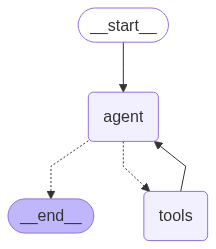

In [11]:
# Visualize the workflow
from IPython.display import Image, display

display(Image(agentic_rag_workflow.get_graph().draw_mermaid_png()))

---

## 6. Testing Agentic RAG

Let's test our Agentic RAG system with various business scenarios to demonstrate how the agent intelligently chooses between RAG and other tools based on the context.


In [12]:
# Test 1: Knowledge-based question (should use RAG)
print("🧪 Test 1: Knowledge-Based Question")
print("="*60)
print("User: What are the key principles of risk management in finance?")
print("\nExpected Behavior:")
print("  - Agent should use business_knowledge_search (RAG tool)")
print("  - Retrieve relevant information from knowledge base")
print("  - Provide comprehensive answer based on retrieved content")

# Execute the workflow
for chunk in agentic_rag_workflow.stream(
    {"messages": [("user", "What are the key principles of risk management in finance?")]},
    stream_mode="values"
):
    if "messages" in chunk and chunk["messages"]:
        last_message = chunk["messages"][-1]
        print(f"\n📝 Step Result:")
        print(f"Message Type: {type(last_message).__name__}")
        
        if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
            print(f"🔧 Tool Calls: {len(last_message.tool_calls)}")
            for tool_call in last_message.tool_calls:
                print(f"  - Tool: {tool_call['name']}")
                print(f"  - Args: {tool_call['args']}")
        else:
            print(f"💬 Content: {last_message.content[:400]}...")

print("\n✅ Test 1 Complete!")

🧪 Test 1: Knowledge-Based Question
User: What are the key principles of risk management in finance?

Expected Behavior:
  - Agent should use business_knowledge_search (RAG tool)
  - Retrieve relevant information from knowledge base
  - Provide comprehensive answer based on retrieved content

📝 Step Result:
Message Type: HumanMessage
💬 Content: What are the key principles of risk management in finance?...

📝 Step Result:
Message Type: AIMessage
🔧 Tool Calls: 1
  - Tool: business_knowledge_search
  - Args: {'query': 'key principles of risk management in finance'}

📝 Step Result:
Message Type: ToolMessage
💬 Content: Risk management is the process of identifying the potential downsides as well as the potential rewards of an investment.
Balancing risk and reward is a crucial process in any investment decision.
Risk management strategies include avoidance, retention, sharing, transferring, and loss prevention and reduction.
One method of measuring risk involves determining standard deviation

In [13]:
# Test 2: Calculation request (should use financial metrics tool)
print("🧪 Test 2: Financial Calculation Request")
print("="*60)
print("User: Calculate the ROI for an investment of $100,000 that grew to $150,000")
print("\nExpected Behavior:")
print("  - Agent should use calculate_financial_metrics tool")
print("  - Perform ROI calculation")
print("  - Provide numerical result with interpretation")

# Execute the workflow
for chunk in agentic_rag_workflow.stream(
    {"messages": [("user", "Calculate the ROI for an investment of $100,000 that grew to $150,000")]},
    stream_mode="values"
):
    if "messages" in chunk and chunk["messages"]:
        last_message = chunk["messages"][-1]
        print(f"\n📝 Step Result:")
        print(f"Message Type: {type(last_message).__name__}")
        
        if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
            print(f"🔧 Tool Calls: {len(last_message.tool_calls)}")
            for tool_call in last_message.tool_calls:
                print(f"  - Tool: {tool_call['name']}")
                print(f"  - Args: {tool_call['args']}")
        else:
            print(f"💬 Content: {last_message.content[:300]}...")

print("\n✅ Test 2 Complete!")


🧪 Test 2: Financial Calculation Request
User: Calculate the ROI for an investment of $100,000 that grew to $150,000

Expected Behavior:
  - Agent should use calculate_financial_metrics tool
  - Perform ROI calculation
  - Provide numerical result with interpretation

📝 Step Result:
Message Type: HumanMessage
💬 Content: Calculate the ROI for an investment of $100,000 that grew to $150,000...

📝 Step Result:
Message Type: AIMessage
🔧 Tool Calls: 1
  - Tool: calculate_financial_metrics
  - Args: {'metric_type': 'ROI', 'values': '100000,150000'}

📝 Step Result:
Message Type: ToolMessage
💬 Content: ROI Calculation: 50.00% (Initial: $100,000.00, Final: $150,000.00)...

📝 Step Result:
Message Type: AIMessage
💬 Content: The Return on Investment (ROI) for your investment of $100,000 that grew to $150,000 is **50.00%**. This indicates that you gained 50% on your initial investment....

✅ Test 2 Complete!


In [14]:
# Test 3: Market analysis request (should use market analysis tool)
print("🧪 Test 3: Market Analysis Request")
print("="*60)
print("User: What's the current trend analysis for Apple stock?")
print("\nExpected Behavior:")
print("  - Agent should use market_analysis tool")
print("  - Retrieve current market data")
print("  - Provide trend analysis and insights")

# Execute the workflow
for chunk in agentic_rag_workflow.stream(
    {"messages": [("user", "What's the current trend analysis for Apple stock?")]},
    stream_mode="values"
):
    if "messages" in chunk and chunk["messages"]:
        last_message = chunk["messages"][-1]
        print(f"\n📝 Step Result:")
        print(f"Message Type: {type(last_message).__name__}")
        
        if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
            print(f"🔧 Tool Calls: {len(last_message.tool_calls)}")
            for tool_call in last_message.tool_calls:
                print(f"  - Tool: {tool_call['name']}")
                print(f"  - Args: {tool_call['args']}")
        else:
            print(f"💬 Content: {last_message.content[:300]}...")

print("\n✅ Test 3 Complete!")


🧪 Test 3: Market Analysis Request
User: What's the current trend analysis for Apple stock?

Expected Behavior:
  - Agent should use market_analysis tool
  - Retrieve current market data
  - Provide trend analysis and insights

📝 Step Result:
Message Type: HumanMessage
💬 Content: What's the current trend analysis for Apple stock?...

📝 Step Result:
Message Type: AIMessage
🔧 Tool Calls: 1
  - Tool: market_analysis
  - Args: {'symbol': 'AAPL', 'analysis_type': 'trend'}

📝 Step Result:
Message Type: ToolMessage
💬 Content: Trend Analysis for AAPL: BULLISH trend, Current price: $175.50...

📝 Step Result:
Message Type: AIMessage
💬 Content: The current trend analysis for Apple Inc. (AAPL) indicates a **bullish trend**. The stock is currently priced at **$175.50**. This suggests positive momentum in the stock's performance, which may be a favorable time for investors considering buying or holding the stock....

✅ Test 3 Complete!


In [15]:
# Test 4: Complex multi-tool request (should use multiple tools)
print("🧪 Test 4: Complex Multi-Tool Request")
print("="*60)
print("User: I want to understand portfolio management principles and calculate the ROI for a $200,000 investment that grew to $280,000")
print("\nExpected Behavior:")
print("  - Agent should use business_knowledge_search for portfolio management concepts")
print("  - Agent should use calculate_financial_metrics for ROI calculation")
print("  - Provide comprehensive response combining both results")

# Execute the workflow
for chunk in agentic_rag_workflow.stream(
    {"messages": [("user", "I want to understand portfolio management principles and calculate the ROI for a $200,000 investment that grew to $280,000")]},
    stream_mode="values"
):
    if "messages" in chunk and chunk["messages"]:
        last_message = chunk["messages"][-1]
        print(f"\n📝 Step Result:")
        print(f"Message Type: {type(last_message).__name__}")
        
        if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
            print(f"🔧 Tool Calls: {len(last_message.tool_calls)}")
            for tool_call in last_message.tool_calls:
                print(f"  - Tool: {tool_call['name']}")
                print(f"  - Args: {tool_call['args']}")
        else:
            print(f"💬 Content: {last_message.content}")

print("\n✅ Test 4 Complete!")

🧪 Test 4: Complex Multi-Tool Request
User: I want to understand portfolio management principles and calculate the ROI for a $200,000 investment that grew to $280,000

Expected Behavior:
  - Agent should use business_knowledge_search for portfolio management concepts
  - Agent should use calculate_financial_metrics for ROI calculation
  - Provide comprehensive response combining both results

📝 Step Result:
Message Type: HumanMessage
💬 Content: I want to understand portfolio management principles and calculate the ROI for a $200,000 investment that grew to $280,000

📝 Step Result:
Message Type: AIMessage
🔧 Tool Calls: 2
  - Tool: business_knowledge_search
  - Args: {'query': 'portfolio management principles'}
  - Tool: calculate_financial_metrics
  - Args: {'metric_type': 'ROI', 'values': '200000,280000'}

📝 Step Result:
Message Type: ToolMessage
💬 Content: ROI Calculation: 40.00% (Initial: $200,000.00, Final: $280,000.00)

📝 Step Result:
Message Type: AIMessage
💬 Content: ### Portfolio

In [16]:
# Test 5: General question (no tools needed)
print("🧪 Test 5: General Business Question (No Tools Required)")
print("="*60)
print("User: What is the difference between capital expenditure and operating expenditure?")
print("\nExpected Behavior:")
print("  - Agent should respond directly without using any tools")
print("  - Provide general business knowledge response")
print("  - Workflow should end immediately")

# Execute the workflow
for chunk in agentic_rag_workflow.stream(
    {"messages": [("user", "What is the difference between capital expenditure and operating expenditure?")]},
    stream_mode="values"
):
    if "messages" in chunk and chunk["messages"]:
        last_message = chunk["messages"][-1]
        print(f"\n📝 Step Result:")
        print(f"Message Type: {type(last_message).__name__}")
        print(f"💬 Content: {last_message.content[:300]}...")

print("\n✅ Test 5 Complete!")

🧪 Test 5: General Business Question (No Tools Required)
User: What is the difference between capital expenditure and operating expenditure?

Expected Behavior:
  - Agent should respond directly without using any tools
  - Provide general business knowledge response
  - Workflow should end immediately

📝 Step Result:
Message Type: HumanMessage
💬 Content: What is the difference between capital expenditure and operating expenditure?...

📝 Step Result:
Message Type: AIMessage
💬 Content: ...

📝 Step Result:
Message Type: ToolMessage
💬 Content: Finally, you can look at each company’s return on invested capital to gauge which firm has historically done a better job investing its money. Comparing these valuations, you then make a short list of companies whose stock you will buy.


  The Bottom Line  
 A lot of information is contained within...

📝 Step Result:
Message Type: AIMessage
💬 Content: Capital Expenditure (CapEx) and Operating Expenditure (OpEx) are two fundamental categories of busin

---

## 7. Key Takeaways

### What We've Accomplished

1. **Transformed RAG into a Tool**: Converted traditional RAG from a mandatory step into an intelligent tool that agents can choose to use
2. **Intelligent Decision Making**: Built agents that autonomously decide when retrieval is needed based on context
3. **Multi-Tool Integration**: Demonstrated how RAG works alongside other tools

### Production Considerations

#### **Performance Optimization**
- **Tool Selection Efficiency**: Minimize unnecessary tool calls
- **Caching Strategies**: Cache frequently accessed knowledge
- **Response Time**: Balance thoroughness with speed

#### **Quality Assurance**
- **Document Grading**: Ensure retrieved information is relevant
- **Answer Validation**: Verify accuracy of generated responses
- **Feedback Loops**: Learn from user interactions to improve

#### **Scalability**
- **Knowledge Base Management**: Handle large document collections
- **Tool Registry**: Manage growing number of available tools

---

## 8. Next Steps

Congratulations! You've successfully built an Agentic RAG system that demonstrates intelligent decision-making and tool selection. Here's what comes next in your AI agent journey:

### Upcoming Topics

- **Multi-Agent Systems**: Multiple agents working together
- **Agent Coordination**: How agents communicate and collaborate
- **Specialized Agent Roles**: Different agents for different business functions
- **Agent Orchestration**: Managing complex multi-agent workflows

### Additional Resources

- **LangGraph Documentation**: [https://langchain-ai.github.io/langgraph/](https://langchain-ai.github.io/langgraph/)
- **LangChain Tools**: [https://python.langchain.com/docs/](https://python.langchain.com/docs/how_to/#tools)

---

**Happy coding!** 🚀
